# ME 323 Module 1 — Choosing the Ground-Truth Model and the Noise Level
### Faculty notebook (staff only — not for students)

The Module 1 student notebooks "test" two class designs against a frozen
**ground-truth (GT) model** — a surrogate for reality, fit to every beam we
have actually broken. This notebook is the receipts for that model: the full
test campaign, the noise level the repeats support, the candidate model
formulations, how they were scored, and why the winner won. It is
self-contained — it loads the two committed campaign CSVs from GitHub and
reproduces the frozen decision end-to-end (≈2–5 min run time; numpy, pandas,
scikit-learn, matplotlib).

**The data.** A 44-beam Latin-hypercube campaign over the student design box
(b ∈ [1.25, 7], H_web ∈ [5, 16] mm; flange B = 10, total height 18, span
150 mm), plus a 19-test follow-up batch: repeats at five geometries, fills in
under-sampled zones, a thin-web frontier probe *below* the box edge
(b = 1.0–1.1), and three beams printed with corrected support settings.
63 tests in all.

> ⚠ **Handling.** This notebook and the campaign CSVs it loads reveal the
> ground truth the students are graded against. They are shared for faculty
> review while the module is in development and will be removed from the
> public repo before the course goes live. Keep them out of anything students
> receive.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120

RAW = ("https://raw.githubusercontent.com/andrewvoss8-boop/"
       "core-me-data-science-activities-public/main/data/")
def load(name):
    try:
        df = pd.read_csv(RAW + name); src = "GitHub"
    except Exception:
        df = pd.read_csv("../../data/" + name); src = "local copy"
    print(f"{name}: {len(df)} rows ({src})")
    return df

# geometry / mass model (identical to the student notebooks)
B_FLANGE, TH, L_SPAN = 10.0, 18.0, 150.0
KMASS = 0.2045                      # g/mm^2 of cross-section at 172 mm printed length
B_LO, B_HI, H_LO, H_HI = 1.25, 7.0, 5.0, 16.0   # student design box
def mass_g(b, H):
    return KMASS * (b * H + B_FLANGE * (TH - H))

camp = load("ground_truth_B10_L150.csv").rename(columns={"b_mm": "b", "H_web_mm": "H"})
add  = load("ibeam150_additional_tests.csv")

allt = pd.concat([camp[["b", "H", "strength_N"]].assign(source="campaign", tag=""),
                  add[["b", "H", "strength_N", "tag"]].assign(source="followup")],
                 ignore_index=True)
allt["sw_true"] = allt.strength_N / mass_g(allt.b, allt.H)
allt["loc"] = allt.b.round(3).astype(str) + "_" + allt.H.round(3).astype(str)
print(f"\ntraining pool: {len(allt)} tests at {allt['loc'].nunique()} distinct geometries")
print("follow-up composition (tag: S1/S2/S3 = repeat sessions, PS = corrected "
      "supports, blank = single tests):")
print(add.tag.fillna("").replace("", "single").value_counts().to_string())

ground_truth_B10_L150.csv: 44 rows (GitHub)
ibeam150_additional_tests.csv: 19 rows (GitHub)

training pool: 63 tests at 52 distinct geometries
follow-up composition (tag: S1/S2/S3 = repeat sessions, PS = corrected supports, blank = single tests):
tag
single    6
S1        4
S2        4
PS        3
S3        2


## 1. Noise, measured from the repeats

Every GP in this study needs a measurement-noise level (`alpha`, the assumed
variance of log strength for a repeated print). The classroom materials assume
**3%**, a number that originally came from just three repeat prints. The
follow-up batch was designed to check it: repeated prints at five geometries,
plus the original campaign print where one exists at the same geometry.

The estimate below is the **within-repeat-group standard deviation of log
strength, pooled across groups weighted by degrees of freedom**. Caveats it
inherits: only five geometries, 11 degrees of freedom in total, and the groups
that include a campaign print mix print batches — so batch-to-batch variation
is (deliberately) inside this number, not separated from it.

In [2]:
groups = []
for (b, H), g in add.groupby(["b", "H"]):
    vals = list(g.strength_N)
    labels = [t if t else "new" for t in g.tag.fillna("")]
    orig = camp[np.isclose(camp.b, b) & np.isclose(camp.H, H)]
    if len(orig):
        vals = list(orig.strength_N) + vals
        labels = [f"campaign#{int(orig.print_order.iloc[0])}"] + labels
    if len(vals) >= 2:
        groups.append(dict(b=b, H=H, n=len(vals), mean_N=np.mean(vals),
                           sd_log=np.std(np.log(vals)),
                           values=np.round(vals, 1).tolist(), sessions=labels))
grp = pd.DataFrame(groups)
print(grp[["b", "H", "n", "mean_N", "sd_log", "values"]].round(3).to_string(index=False))

ss  = sum((r.n - 1) * r.sd_log**2 for _, r in grp.iterrows())
dof = sum(r.n - 1 for _, r in grp.iterrows())
sigma_pooled = float(np.sqrt(ss / dof))
print(f"\npooled print-to-print noise: {sigma_pooled*100:.1f}% (log-space sd, {dof} dof)")
print("the classroom assumption of 3% holds up; the ablation below also carries a "
      "3.5% variant to check the choice matters little")

   b     H  n  mean_N  sd_log                              values
1.25 13.40  2 485.800   0.031                      [470.8, 500.8]
1.30 12.80  5 551.420   0.028 [548.6, 524.2, 565.2, 566.1, 553.0]
1.74 14.88  3 391.433   0.042               [376.1, 383.8, 414.4]
2.05 10.10  2 703.850   0.062                      [747.5, 660.2]
2.70  9.40  4 801.325   0.025        [833.7, 782.5, 787.3, 801.8]

pooled print-to-print noise: 3.5% (log-space sd, 11 dof)
the classroom assumption of 3% holds up; the ablation below also carries a 3.5% variant to check the choice matters little


## 2. The candidate formulations

Same question the students face in Submission 1, asked at full scale: where —
if anywhere — do the physics equations belong inside the model? Each
candidate below is one answer; the GP-based ones come in RBF and Matérn
(ν = 2.5) kernel flavors. The Matérn allows rougher functions than the very
smooth RBF — with real failure modes switching across the map, that
flexibility is worth testing rather than assuming.

| variant | inputs → target | student-notebook analogue |
|---|---|---|
| `phys` | min(P_vm, P_LTB), no fitting | Pre-lab 1 equations (uncalibrated) |
| `phys_cal` | physics × one fitted log-space scale | a one-knob calibration |
| `gp_sw` | GP (b, H) → log str/w | Submission 1 lane A |
| `gp_str` | GP (b, H) → log strength | lane B |
| `gpf_sw` | GP (b, H, log P_phys, stab) → log str/w | lane C (physics features) |
| `gpr_str` | GP (b, H) → log(strength / P_phys) | lane D (residual) |

Shared recipe, identical to the student notebooks: z-scored inputs, log
target, mean-centered, `alpha = 0.03²` unless stated, 5 optimizer restarts,
fixed seed. The physics here is the *uncalibrated* handbook version
(σ_y = 76 MPa, fixture k = 0.33) — the GT must not depend on the class's
calibration exercise.

In [3]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel as CK, RBF, Matern

# ---- physics (identical to ibeam150_common.py / the student notebooks) ----
SY, E_MOD = 76e6, 2.5e9
G_MOD, C1_LTB, C2_LTB, K_FIX = E_MOD / 2.6, 1.35, 0.55, 0.33

def section_props(b, H):
    tf = (TH - H) / 2.0
    b_, h_, B_, tf_ = b / 1e3, H / 1e3, B_FLANGE / 1e3, tf / 1e3
    c = (TH / 1e3) / 2.0
    Ix = (b_*h_**3)/12 + 2*((B_*tf_**3)/12 + B_*tf_*(h_/2 + tf_/2)**2)
    Iy = (h_*b_**3)/12 + 2*(tf_*B_**3)/12
    beta = lambda t, a: 1 - 0.63*(t/a) + 0.052*(t/a)**5
    J  = (1/3)*beta(b_, h_)*h_*b_**3 + (2/3)*beta(tf_, B_)*B_*tf_**3
    Cw = Iy*(h_ + tf_)**2/4
    return dict(Ix=Ix, Iy=Iy, J=J, Cw=Cw, c=c, b=b_, h=h_)

def phys_parts(b, H, k=K_FIX):
    p = section_props(b, H)
    Pb = 4*SY*p["Ix"]/(p["c"]*L_SPAN/1e3)
    Ps = 2*SY*p["b"]*p["h"]/np.sqrt(3)
    Pvm = 1.0/np.sqrt(1/Pb**2 + 1/Ps**2)
    My = SY*p["Ix"]/p["c"]
    Lb, zg = k*L_SPAN/1e3, p["c"]
    R = p["Cw"]/p["Iy"] + (Lb**2*G_MOD*p["J"])/(np.pi**2*E_MOD*p["Iy"]) + (C2_LTB*zg)**2
    Mcr = C1_LTB*np.pi**2*E_MOD*p["Iy"]/Lb**2 * (np.sqrt(R) - C2_LTB*zg)
    Pl = 4*min(My, Mcr)/(L_SPAN/1e3)
    return Pb, Ps, Pvm, Pl

# ---- the model zoo ----
def _make_gp(n_dims, kernel_kind, alpha, n_restarts=5, seed=0):
    if kernel_kind == "rbf":
        ker = CK(1.0, (1e-3, 1e3)) * RBF([1.0]*n_dims, (1e-1, 30.0))
    else:
        ker = CK(1.0, (1e-3, 1e3)) * Matern([1.0]*n_dims, (1e-2, 30.0), nu=2.5)
    return GaussianProcessRegressor(ker, alpha=alpha, normalize_y=False,
                                    n_restarts_optimizer=n_restarts, random_state=seed)

class BeamModel:
    """One zoo entry. fit(df) then predict(b, H) -> (strength_N, sw[, sigma_log])."""
    def __init__(self, variant, kernel_kind="rbf", alpha=0.03**2):
        self.variant, self.kernel_kind, self.alpha = variant, kernel_kind, alpha

    def _phys_cols(self, b, H):
        parts = np.array([phys_parts(bb, HH) for bb, HH in zip(b, H)])
        Pb, Ps, Pvm, Pl = parts.T
        return np.minimum(Pvm, Pl), Pl / Pb          # P_phys, stab

    def _X(self, b, H):
        b, H = np.asarray(b, float), np.asarray(H, float)
        if self.variant in ("gp_sw", "gp_str", "gpr_str"):
            return np.column_stack([b, H])
        Pphys, stab = self._phys_cols(b, H)
        return np.column_stack([b, H, np.log(Pphys), stab])

    def fit(self, df):
        b, H, y_str = df.b.values, df.H.values, df.strength_N.values
        if self.variant == "phys":
            return self
        if self.variant == "phys_cal":
            Pphys, _ = self._phys_cols(b, H)
            self.scale_ = float(np.exp(np.mean(np.log(y_str) - np.log(Pphys))))
            return self
        if self.variant in ("gp_sw", "gpf_sw"):
            y = np.log(y_str / mass_g(b, H))
        elif self.variant in ("gp_str", "gpf_str"):
            y = np.log(y_str)
        else:                                        # gpr_str
            Pphys, _ = self._phys_cols(b, H)
            y = np.log(y_str) - np.log(Pphys)
        X = self._X(b, H)
        self.fmu_, self.fsd_ = X.mean(0), X.std(0) + 1e-12
        self.ymean_ = y.mean()
        self.gp = _make_gp(X.shape[1], self.kernel_kind, self.alpha)
        self.gp.fit((X - self.fmu_) / self.fsd_, y - self.ymean_)
        return self

    def predict(self, b, H, return_std=False):
        b, H = np.atleast_1d(np.asarray(b, float)), np.atleast_1d(np.asarray(H, float))
        m = mass_g(b, H)
        if self.variant == "phys":
            Pphys, _ = self._phys_cols(b, H)
            s, sig = Pphys, np.zeros(len(b))
        elif self.variant == "phys_cal":
            Pphys, _ = self._phys_cols(b, H)
            s, sig = self.scale_ * Pphys, np.zeros(len(b))
        else:
            mu, sig = self.gp.predict((self._X(b, H) - self.fmu_) / self.fsd_,
                                      return_std=True)
            mu = mu + self.ymean_
            if self.variant in ("gp_sw", "gpf_sw"):
                s = np.exp(mu) * m
            elif self.variant in ("gp_str", "gpf_str"):
                s = np.exp(mu)
            else:
                Pphys, _ = self._phys_cols(b, H)
                s = Pphys * np.exp(mu)
        return (s, s/m, sig) if return_std else (s, s/m)

ZOO = {
    "phys_pure":         dict(variant="phys"),
    "phys_calibrated":   dict(variant="phys_cal"),
    "gp_sw_rbf":         dict(variant="gp_sw",  kernel_kind="rbf"),
    "gp_sw_matern":      dict(variant="gp_sw",  kernel_kind="matern"),
    "gp_sw_matern_a3.5": dict(variant="gp_sw",  kernel_kind="matern", alpha=0.035**2),
    "gp_str_matern":     dict(variant="gp_str", kernel_kind="matern"),
    "gpf_sw_rbf":        dict(variant="gpf_sw", kernel_kind="rbf"),
    "gpf_sw_matern":     dict(variant="gpf_sw", kernel_kind="matern"),
    "gpr_str_rbf":       dict(variant="gpr_str", kernel_kind="rbf"),
    "gpr_str_matern":    dict(variant="gpr_str", kernel_kind="matern"),
}
print(len(ZOO), "candidates:", ", ".join(ZOO))

10 candidates: phys_pure, phys_calibrated, gp_sw_rbf, gp_sw_matern, gp_sw_matern_a3.5, gp_str_matern, gpf_sw_rbf, gpf_sw_matern, gpr_str_rbf, gpr_str_matern


## 3. Scoring: leave-one-LOCATION-out

With repeats in the pool, plain leave-one-out is subtly rigged: hide one print
of a repeated geometry and its siblings stay in training, so the model gets
credit for memorizing that site rather than for generalizing. The fix is
**leave-one-location-out (LOLO)**: all prints of a geometry leave together
(52 folds instead of 63). The cell below runs LOLO for every candidate — and,
for the two leading GPs, also runs plain LOO so you can see the size of the
leak the protocol removes.

Errors are scored in strength-to-weight space (N/g), the quantity the module
optimizes.

phys_pure            LOLO sw RMSE 6.257  MAPE 15.77%  R2 -2.052
phys_calibrated      LOLO sw RMSE 3.831  MAPE 8.93%  R2 -0.144


gp_sw_rbf            LOLO sw RMSE 2.878  MAPE 7.15%  R2 +0.354


gp_sw_matern         LOLO sw RMSE 2.672  MAPE 6.61%  R2 +0.444


gp_sw_matern_a3.5    LOLO sw RMSE 2.628  MAPE 6.52%  R2 +0.462


gp_str_matern        LOLO sw RMSE 3.285  MAPE 8.22%  R2 +0.159


...

gpf_sw_matern        LOLO sw RMSE 2.525  MAPE 6.15%  R2 +0.503


gpr_str_rbf          LOLO sw RMSE 2.914  MAPE 7.33%  R2 +0.338


gpr_str_matern       LOLO sw RMSE 2.702  MAPE 6.96%  R2 +0.431

WINNER: gpf_sw_matern  (LOLO sw RMSE 2.525 N/g on 63 tests)
(the frozen class GT recorded in gt_model_choice.json: gpf_sw_matern, RMSE 2.525)

plain LOO vs LOLO (the repeat leak):


  gpf_sw_matern    plain LOO 2.467  vs  LOLO 2.525 N/g


  gp_sw_matern     plain LOO 2.612  vs  LOLO 2.672 N/g


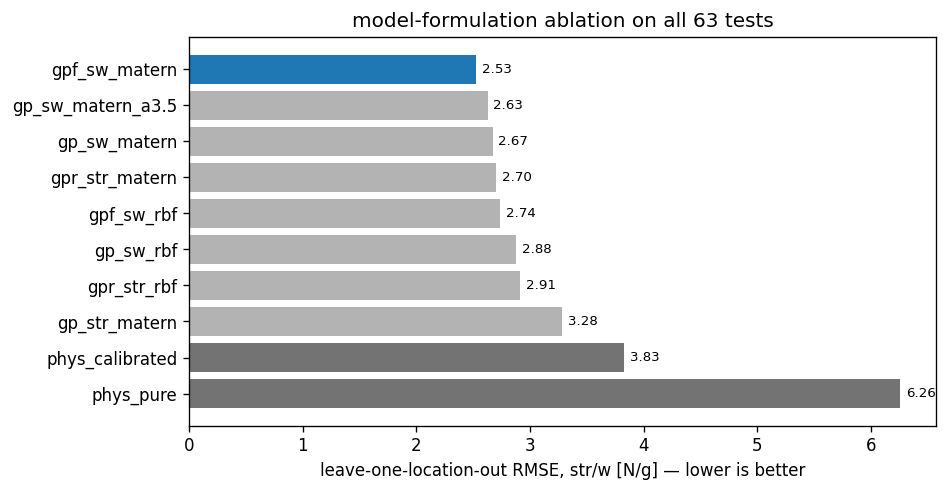

In [4]:
def metrics(y_true, y_pred, prefix=""):
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    err = y_pred - y_true
    ss = np.sum((y_true - y_true.mean())**2)
    return {prefix + "rmse": float(np.sqrt(np.mean(err**2))),
            prefix + "mae": float(np.mean(np.abs(err))),
            prefix + "mape_pct": float(np.mean(np.abs(err / y_true)) * 100),
            prefix + "r2": float(1 - np.sum(err**2)/ss)}

locs = allt["loc"].unique()
rows = []
for name, kw in ZOO.items():
    preds = np.zeros(len(allt))
    for L in locs:
        te = (allt["loc"] == L).values
        mdl = BeamModel(**kw).fit(allt[~te])
        _, sw = mdl.predict(allt.b.values[te], allt.H.values[te])
        preds[te] = sw
    rows.append({"model": name, **metrics(allt.sw_true, preds, "sw_")})
    print(f"{name:20s} LOLO sw RMSE {rows[-1]['sw_rmse']:.3f}  "
          f"MAPE {rows[-1]['sw_mape_pct']:.2f}%  R2 {rows[-1]['sw_r2']:+.3f}")

tbl = pd.DataFrame(rows).sort_values("sw_rmse").reset_index(drop=True)
winner = tbl.iloc[0]
print(f"\nWINNER: {winner.model}  (LOLO sw RMSE {winner.sw_rmse:.3f} N/g on {len(allt)} tests)")
print("(the frozen class GT recorded in gt_model_choice.json: gpf_sw_matern, RMSE 2.525)")

# the leak plain LOO would have hidden
print("\nplain LOO vs LOLO (the repeat leak):")
for name in ["gpf_sw_matern", "gp_sw_matern"]:
    preds = np.zeros(len(allt))
    for i in range(len(allt)):
        mdl = BeamModel(**ZOO[name]).fit(allt.drop(allt.index[i]))
        _, sw = mdl.predict(allt.b.iloc[i], allt.H.iloc[i])
        preds[i] = sw[0]
    loo_rmse = np.sqrt(np.mean((preds - allt.sw_true.values)**2))
    lolo_rmse = tbl.loc[tbl.model == name, "sw_rmse"].iloc[0]
    print(f"  {name:16s} plain LOO {loo_rmse:.3f}  vs  LOLO {lolo_rmse:.3f} N/g")

fig, ax = plt.subplots(figsize=(8, 4.2))
t2 = tbl.iloc[::-1]
cols = ["tab:blue" if m == winner.model else
        ("0.45" if m.startswith("phys") else "0.7") for m in t2.model]
ax.barh(t2.model, t2.sw_rmse, color=cols)
for y, (m, v) in enumerate(zip(t2.model, t2.sw_rmse)):
    ax.annotate(f"{v:.2f}", (v + 0.05, y), va="center", fontsize=8)
ax.set_xlabel("leave-one-location-out RMSE, str/w [N/g] — lower is better")
ax.set_title(f"model-formulation ablation on all {len(allt)} tests")
plt.tight_layout(); plt.show()

## 4. What the winner is — and how stable this choice has been

**`gpf_sw_matern`, precisely:** a GP with inputs **(b, H, log P_phys, stab)**
where `P_phys = min(P_vm, P_LTB(k=0.33))` and `stab = P_LTB / P_bend`
(uncalibrated handbook physics), target **log(strength / mass)**, kernel
**Constant × Matérn(ν = 2.5)** with per-dimension length scales, **alpha =
0.03²**, inputs z-scored, target mean-centered. It is not pickled anywhere —
it is refit deterministically from the training CSV (fixed seed), which is
why this notebook can reproduce it exactly.

**Honesty about stability.** The winner has moved as the data grew:

| data state | winner |
|---|---|
| 43 beams (before beam 23's trace was recovered) | `gpf_sw_rbf` |
| 44 beams, plain LOOCV | `gp_sw_matern` |
| 63 tests, leave-one-location-out | `gpf_sw_matern` |

Read the ablation bars accordingly: the top GP variants sit within a few
tenths of a N/g of each other, and single influential beams have reordered
them before. What has stayed stable across every re-evaluation: (1) a GP
beats pure or calibrated physics by a wide margin, (2) the str/w target beats
the raw-strength target, and (3) physics features help most at the edges of
the data — which is where the follow-up batch added its tests, and likely why
the feature variant retook the lead on the full pool. The class-facing
consequences of swapping among the top two or three GPs are small; the frozen
values in `ground_truth.py` are GT-mean predictions, re-derived whenever the
choice changes.

GT optimum inside the student box: 40.38 N/g at (1.78, 12.40)
GT optimum extended to b = 1.0:    40.38 N/g at (1.78, 12.40)

GT means at the two frozen class designs (values hardcoded in the student notebooks / ground_truth.py):
  equation beam (1.2500, 13.4000):  GT 37.64 N/g / 483.0 N   (frozen: 37.64 / 483.0)
  GP beam (1.4449, 13.3898):  GT 38.12 N/g / 510.2 N   (frozen: 38.12 / 509.7)
  (the ~0.5 N gap on the GP beam is freezing-step bookkeeping: 509.7 N = 38.12 N/g x mass at the rounded display coords (13.3705 g) = 509.7 N; the model values match)


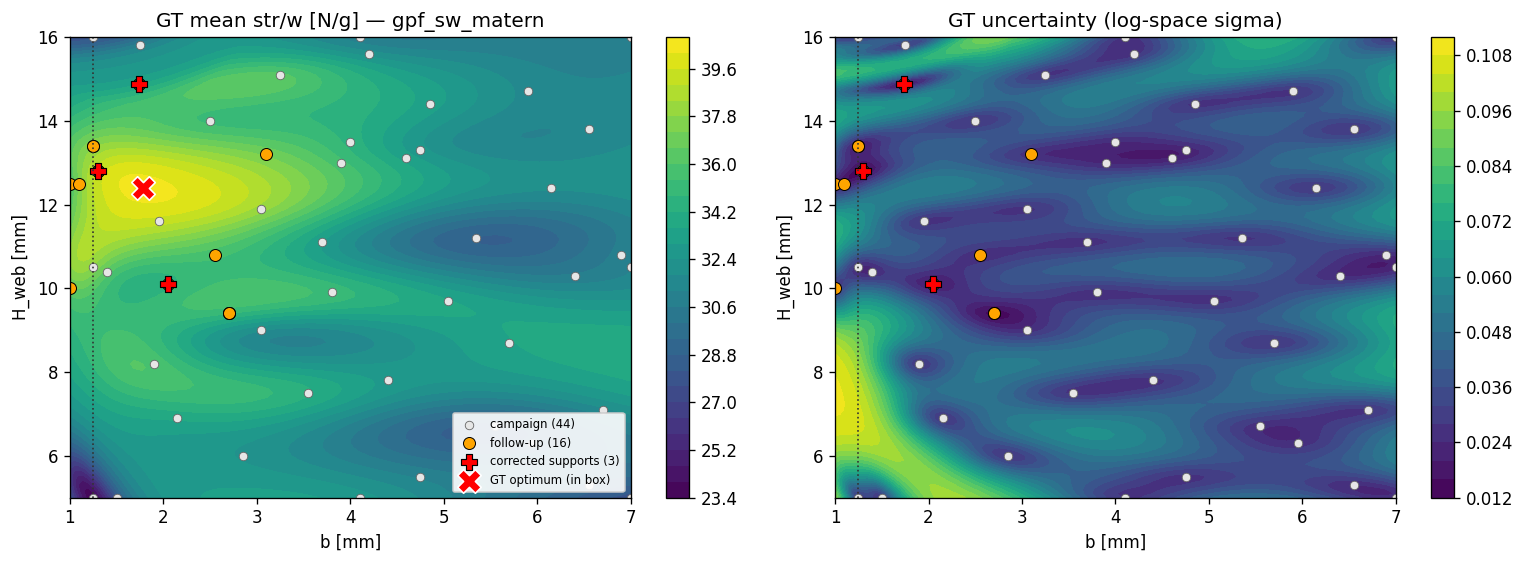

In [5]:
GT = BeamModel(**ZOO[winner.model]).fit(allt)

bg = np.linspace(1.0, B_HI, 124); Hg = np.linspace(H_LO, H_HI, 111)
BB, HH = np.meshgrid(bg, Hg)
_, SWf, SIGf = GT.predict(BB.ravel(), HH.ravel(), return_std=True)
SW, SIG = SWf.reshape(BB.shape), SIGf.reshape(BB.shape)

SW_box = np.where(BB >= B_LO, SW, -np.inf)
io = np.unravel_index(np.argmax(SW_box), SW.shape)
io_all = np.unravel_index(np.argmax(SW), SW.shape)
print(f"GT optimum inside the student box: {SW[io]:.2f} N/g at ({BB[io]:.2f}, {HH[io]:.2f})")
print(f"GT optimum extended to b = 1.0:    {SW[io_all]:.2f} N/g at ({BB[io_all]:.2f}, {HH[io_all]:.2f})")

print("\nGT means at the two frozen class designs (values hardcoded in the "
      "student notebooks / ground_truth.py):")
# the GP beam's display coordinates (1.44, 13.39) are rounded; the frozen value
# was computed at the exact Pre-lab 2 grid point, so query that
bg60, Hg60 = np.linspace(B_LO, B_HI, 60), np.linspace(H_LO, H_HI, 60)
b_gp = bg60[np.argmin(np.abs(bg60 - 1.44))]; H_gp = Hg60[np.argmin(np.abs(Hg60 - 13.39))]
for (bq, Hq), label, frz_sw, frz_N in [((1.25, 13.40), "equation beam", 37.64, 483.0),
                                       ((b_gp, H_gp),  "GP beam",       38.12, 509.7)]:
    s, sw = GT.predict([bq], [Hq])
    print(f"  {label} ({bq:.4f}, {Hq:.4f}):  GT {sw[0]:.2f} N/g / {s[0]:.1f} N   "
          f"(frozen: {frz_sw} / {frz_N})")
print(f"  (the ~0.5 N gap on the GP beam is freezing-step bookkeeping: "
      f"509.7 N = 38.12 N/g x mass at the rounded display coords "
      f"({mass_g(1.44, 13.39):.4f} g) = {38.12*mass_g(1.44, 13.39):.1f} N; "
      f"the model values match)")

fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
for a, Z, ttl in [(ax[0], SW, f"GT mean str/w [N/g] — {winner.model}"),
                  (ax[1], SIG, "GT uncertainty (log-space sigma)")]:
    cf = a.contourf(BB, HH, Z, levels=30, cmap="viridis")
    plt.colorbar(cf, ax=a)
    old = allt[allt.source == "campaign"]; new = allt[allt.source == "followup"]
    a.scatter(old.b, old.H, s=26, c="0.9", edgecolor="0.4", lw=0.5, label="campaign (44)")
    a.scatter(new[new.tag != "PS"].b, new[new.tag != "PS"].H, s=52, c="orange",
              edgecolor="k", lw=0.6, label="follow-up (16)")
    a.scatter(new[new.tag == "PS"].b, new[new.tag == "PS"].H, s=100, marker="P",
              c="red", edgecolor="k", lw=0.7, label="corrected supports (3)")
    a.axvline(B_LO, color="0.2", ls=":", lw=1)
    a.set_xlabel("b [mm]"); a.set_ylabel("H_web [mm]"); a.set_title(ttl)
ax[0].scatter([BB[io]], [HH[io]], marker="X", s=200, c="red", edgecolor="w",
              zorder=5, label="GT optimum (in box)")
ax[0].legend(fontsize=7, loc="lower right", framealpha=0.9)
plt.tight_layout(); plt.show()

## 5. Caveats that should travel with this model

1. **The support-setting confound.** During the campaign, print supports were
   generating as individual lines instead of the intended zigzag. Three
   follow-up beams were printed with corrected supports (`PS`); the cell below
   compares each against same-geometry prints with the old supports. All
   three are weaker — consistently enough that it does not look like
   print-to-print noise — so a GT trained almost entirely on old-support
   beams may sit several percent **high in absolute newtons** for
   corrected-support prints. Three beams is a small sample and print session
   is confounded with the setting change; more PS replicates are on the list
   before anything depending on absolute strength is frozen. The *relative*
   landscape (where the good designs are) is less exposed.
2. **The thin-web frontier is uncertain, and only the data knows how.** Of
   the follow-up probes below the box edge (b = 1.0–1.1), the taller-web ones
   carried well under what campaign-calibrated physics promises — failing by
   flange–web separation, a mode no yield formula flags — while the
   shortest-web probe over-performed instead (numbers below). The frontier is
   not uniformly weak; it is unpredictable by the equations, which is the
   stronger argument for keeping the GT anchored to tests.
3. **Noise: 3.5% measured vs 3% assumed.** Compare the `gp_sw_matern` and
   `gp_sw_matern_a3.5` rows in the ablation — the difference is far below the
   resolution of this comparison, so the classroom 3% stands.
4. **Selection measures interpolation.** LOLO scores predictions at
   geometries surrounded by other tested geometries. Extrapolation quality
   outside the tested cloud is not scored — one reason the frozen class
   queries return GT values only at well-supported points.

In [6]:
# corrected-support (PS) beams vs same-geometry old-support prints
print("PS vs old-support prints, same geometry (z in units of pooled noise):")
zs = []
for (b, H) in add[add.proper_supports][["b", "H"]].itertuples(index=False):
    g = add[(add.b == b) & (add.H == H)]
    ps = g[g.proper_supports].iloc[0]
    old_N = list(g[~g.proper_supports].strength_N) + \
            list(camp[np.isclose(camp.b, b) & np.isclose(camp.H, H)].strength_N)
    dlog = np.log(ps.strength_N) - np.mean(np.log(old_N))
    z = dlog / sigma_pooled
    zs.append(z)
    print(f"  ({b}, {H}):  PS {ps.strength_N:.1f} N vs old mean {np.mean(old_N):.1f} N "
          f"(n={len(old_N)})  ->  {np.exp(dlog)*100-100:+.1f}%  (z = {z:+.2f})")
print(f"combined z = {sum(zs)/np.sqrt(len(zs)):+.2f}  (all three weaker)")

# the thin-web frontier: measured vs physics calibrated on the pre-frontier campaign
pc = BeamModel(variant="phys_cal").fit(allt[allt.source == "campaign"])
frontier = add[add.b <= 1.1]
print("\nthin-web frontier (below the b = 1.25 box edge):")
for _, r in frontier.iterrows():
    _, sw_pc = pc.predict([r.b], [r.H])
    print(f"  ({r.b}, {r.H}):  measured {r.sw:.1f} N/g   vs  campaign-calibrated "
          f"physics {sw_pc[0]:.1f} N/g   — {r.failure_note[:60]}")

PS vs old-support prints, same geometry (z in units of pooled noise):
  (1.3, 12.8):  PS 524.2 N vs old mean 558.2 N (n=4)  ->  -6.1%  (z = -1.81)
  (1.74, 14.88):  PS 376.1 N vs old mean 399.1 N (n=2)  ->  -5.7%  (z = -1.69)
  (2.05, 10.1):  PS 660.2 N vs old mean 747.5 N (n=1)  ->  -11.7%  (z = -3.58)
combined z = -4.09  (all three weaker)

thin-web frontier (below the b = 1.25 box edge):
  (1.0, 10.0):  measured 36.4 N/g   vs  campaign-calibrated physics 31.8 N/g   — Seperation of the top flange from the web. Vertical crack al
  (1.0, 12.5):  measured 34.4 N/g   vs  campaign-calibrated physics 41.7 N/g   — Seperation of the top flange from the web. Interface between
  (1.1, 12.5):  measured 38.5 N/g   vs  campaign-calibrated physics 42.3 N/g   — Vertical crack, however, it was toward the end of the beam, 


## Provenance

- **Data:** `data/ground_truth_B10_L150.csv` (44-beam campaign, with the
  recovered beam-23 trace and the 847.5 N duplicate resolved to beam 29) and
  `data/ibeam150_additional_tests.csv` (19 follow-up tests, 2026-07-08), both
  in this repo. Raw Instron traces live in the staff archive, not here.
- **This notebook** distills the staff analysis pipeline (notebooks 15–16 of
  `me323/ibeam150_analysis/`, kept off the public repo) into a shareable,
  reproducible record. The full pipeline also covers the 847.5 N duplicate
  resolution, subset-design Monte Carlo studies, and the class dry run.
- **Consumption:** students never query this model. The two class-wide
  designs were evaluated once against the GT mean and the resulting numbers
  frozen into the student notebooks (staff record:
  `me323/Module1_drafts/ground_truth.py`).
- **Before go-live:** this notebook and both campaign CSVs come off the
  public repo so students cannot look up the answer surface.